# Planes de pensiones vs fondos indexados: la cuenta que importa

Estás cerca de los 30. Terminaste tus estudios, llevas ya unos años en el mercado laboral, has conseguido un buen salario y, por primera vez, empiezas a mirar tu dinero con otra perspectiva. Ya no se trata solo de llegar a fin de mes, ahorrar algo y darte algún capricho. Empiezas a pensar en serio en cómo quieres construir tu patrimonio, cuánto margen de libertad puedes comprar con tus inversiones y, sobre todo, cuándo podrías permitirte dejar de trabajar si algún día quisieras hacerlo.

Y entonces aparece una decisión aparentemente sencilla, pero con muchas implicaciones: ¿te interesa invertir parte de tu dinero en un plan de pensiones de empresa, o sería mejor invertirlo por tu cuenta en un fondo indexado?

Sobre el papel, el plan de pensiones parece atractivo: ventajas fiscales, posible aportación de la empresa y una forma automática de invertir para el futuro. Pero también tiene restricciones: menor liquidez, tributación al rescatarlo y menos flexibilidad que una cartera propia. Por otro lado, invertir en un fondo indexado te da más control, más libertad y más capacidad de adaptar tu estrategia, pero sin ciertas ventajas fiscales iniciales.

La pregunta no es simplemente cuál da más rentabilidad. La pregunta real es: teniendo en cuenta impuestos, aportaciones, costes, liquidez y horizonte temporal, qué opción te acerca más a la independencia financiera?

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display as ipy_display

from pension_vs_index.analysis import (
    ScenarioConfig,
    accumulation_summary,
    lump_sum_results,
    normalize_lump_sum_extraction_results,
    normalize_percentage_extraction_results,
    percentage_fee_return_sensitivity_grid_results,
    percentage_withdrawal_results,
    simulate_all_accumulation,
    working_retirement_salary_sensitivity_results,
)
from pension_vs_index.taxing_entity.hacienda_espanola import HaciendaEspanola
from pension_vs_index.visualization import (
    apply_money_axis,
    format_extraction_rate_label,
    format_salary_extraction_chart_name,
    plot_accumulation_history,
    plot_extraction_comparison_breakdown,
    plot_fee_return_sensitivity,
    plot_salary_heatmaps,
)

pd.options.display.float_format = "{:,.2f}".format
pd.options.display.notebook_repr_html = False
plt.style.use("seaborn-v0_8-whitegrid")

COLUMNAS_ES = {
    "vehicle": "Vehículo",
    "year": "Año",
    "gross_contributed": "Aportación bruta acumulada",
    "invested_amount": "Importe invertido acumulado",
    "contribution_tax": "Impuestos/cotizaciones en aportación",
    "fees": "Comisiones",
    "pre_withdrawal_value": "Valor antes del rescate",
    "gross_extraction": "Rescate bruto",
    "extraction_tax": "Impuestos del rescate",
    "extraction_fees": "Comisiones de salida",
    "final_after_tax_money": "Dinero neto final",
    "effective_after_tax_cagr": "CAGR neto efectivo",
    "withdrawal_rate": "Porcentaje de extracción",
    "net_received": "Dinero neto recibido",
    "effective_tax_rate": "Tipo efectivo",
    "scenario": "Escenario",
    "annual_contribution": "Aportación anual",
    "contribution_salary": "Salario antes del retiro",
    "withdrawal_salary": "Salario después del retiro",
    "pension_advantage": "Ventaja del plan",
    "expected_return": "Rentabilidad esperada",
    "pension_fee_premium": "Sobrecoste de comisión del plan",
}


def tabla_es(df: pd.DataFrame, columns: list[str] | None = None) -> pd.DataFrame:
    """Renombra las columnas de la tabla de resultados al español.

    Si se especifica `columns`, solo se renombrarán esas columnas. Si no, se renombrarán todas las
    columnas.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con las columnas a renombrar.
    columns : list[str] | None, optional
        Lista de columnas a renombrar. Si es None, se renombrarán todas las
        columnas, por defecto None.

    Returns
    -------
    pd.DataFrame
        DataFrame con las columnas renombradas al español.
    """
    table = df.loc[:, columns].copy() if columns is not None else df.copy()
    return table.rename(columns=COLUMNAS_ES)


def euros_texto(value: float | None) -> str:
    """Convierte un valor numérico a una cadena de texto con formato de euros.

    Parameters
    ----------
    value : float | None
        Valor numérico a convertir. Si es None, se devolverá "En adelante".

    Returns
    -------
    str
        Cadena de texto con el valor en formato de euros.
    """
    if value is None:
        return "En adelante"
    return f"{value:,.0f} EUR".replace(",", ".")


def porcentaje_texto(value: float) -> str:
    """Convierte un valor numérico a una cadena de texto con formato de porcentaje.

    Parameters
    ----------
    value : float
        Valor numérico a convertir.

    Returns
    -------
    str
        Cadena de texto con el valor en formato de porcentaje.
    """
    return f"{value:.1%}".replace(".", ",")

## Supuestos numéricos y metodológicos

Antes de sacar conclusiones, conviene dejar claras las reglas del juego. Este notebook no intenta predecir cómo cambiará el sistema fiscal en el futuro, cuál será la inflación concreta de las próximas décadas ni a qué edad exacta podrá jubilarse cada persona. El análisis está hecho en términos reales: es decir, usando rentabilidades ajustadas por inflación. Bajo este enfoque, no hace falta proyectar precios nominales futuros, porque todos los importes se comparan en euros de poder adquisitivo constante.

Estos son los supuestos que usa el notebook:

- **Mismo activo bruto**: tanto el fondo de inversión como el plan de pensiones invierten en el mismo activo antes de comisiones e impuestos.
- **Rentabilidad base**: `6,8%` anual real, tomada como escenario central a partir del comportamiento del MSCI World en los últimos 40 años.
- **Rentabilidades de referencia**: `5,1%` anual como referencia histórica real del MSCI World, `6,8%` anual como escenario central de los experimentos y `8,5%` anual como referencia del S&P 500 en los últimos 40 años.
- **Rango de sensibilidad**: de `5%` a `9%`, lo bastante amplio como para ver cuándo cambia la frontera entre plan y fondo.
- **Aportación anual del escenario combinado**: `10.000 EUR`, divididos en `1.500 EUR` de plan personal y `8.500 EUR` de plan de empresa.
- **Comisión del fondo de inversión**: `0,12%` anual.
- **Comisión del plan personal**: `0,38%` anual, usando como referencia el plan de pensiones global de MyInvestor.
- **Comisión del plan de empresa**: `0,563%` anual, usando como referencia la cartera de renta variable 100% de Indexa Capital.
- **Comisión del plan combinado**: `0,535%` anual, ponderando `1.500 EUR` al `0,38%` y `8.500 EUR` al `0,563%`.
- **Comisiones de entrada y salida**: `0%`.
- **Volatilidad**: `0%`. No se simulan años buenos y malos; se usa una trayectoria determinista para aislar el efecto fiscal.
- **Horizontes principales**: `40 años` para jubilación ordinaria y `20 años` para escenarios de retirada temprana.

## Parámetros editables

Los diccionarios del notebook controlan todos los experimentos. Para evitar duplicar información, las condiciones principales de cada escenario aparecen en el título de la gráfica correspondiente.

In [2]:
PRIMARY_SCENARIO = {
    "name": "Salario antes del retiro 60k · salario después del retiro 47k · 40 años",
    "config": {
        "gross_salary_during_contribution": 60_000.0,
        "existing_gross_salary_during_withdrawal": 47_000.0,
        "annual_contribution": 10_000.0,
        "investment_horizon_years": 40,
        "contribution_years": 40,
        "expected_annual_return": 0.068,
        "annual_return_volatility": 0.0,
        "regular_fund_annual_fee": 0.0012,
        "pension_plan_annual_fee": 0.00535,
        "regular_entry_fee": 0.0,
        "regular_exit_fee": 0.0,
        "pension_entry_fee": 0.0,
        "pension_exit_fee": 0.0,
    },
    "withdrawal_rates": [0.04],
}

FINAL_EXTRACTION_CASES = [
    {
        "name": "Salario antes del retiro 150k · salario después del retiro 47k · 40 años",
        "config": {
            "gross_salary_during_contribution": 150_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "contribution_years": 40,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00535,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "withdrawal_rates": [0.04],
    },
    {
        "name": "Salario antes del retiro 61k · salario después del retiro 0 · 20 años",
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 0.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 20,
            "contribution_years": 20,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00535,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "withdrawal_rates": [0.068],
    },
    {
        "name": "Salario antes del retiro 61k · salario después del retiro 18,5k · 20 años",
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 18_500.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 20,
            "contribution_years": 20,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00535,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "withdrawal_rates": [0.04],
    },
]

SALARY_HEATMAP_EXPERIMENTS = [
    {
        "name": "Plan de pensiones personal",
        "config": {
            "annual_contribution": 1_500.0,
            "investment_horizon_years": 40,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.0038,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "contribution_salary_min": 1_000.0,
            "contribution_salary_max": 150_000.0,
            "withdrawal_salary_min": 1_000.0,
            "withdrawal_salary_max": 75_000.0,
            "contribution_salary_ticks": [1_000.0, 50_000.0, 100_000.0, 150_000.0],
            "withdrawal_salary_ticks": [1_000.0, 25_000.0, 50_000.0, 75_000.0],
            "steps": 100,
        },
    },
    {
        "name": "Plan de pensiones de empresa",
        "config": {
            "annual_contribution": 8_500.0,
            "investment_horizon_years": 40,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00563,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "contribution_salary_min": 1_000.0,
            "contribution_salary_max": 200_000.0,
            "withdrawal_salary_min": 1_000.0,
            "withdrawal_salary_max": 100_000.0,
            "contribution_salary_ticks": [1_000.0, 50_000.0, 100_000.0, 200_000.0],
            "withdrawal_salary_ticks": [1_000.0, 25_000.0, 50_000.0, 100_000.0],
            "steps": 100,
        },
    },
]

FEE_RETURN_EXPERIMENTS = [
    {
        "name": "Salario antes del retiro 60k · salario después del retiro 47k · extracción 4%",
        "withdrawal_rate": 0.04,
        "config": {
            "gross_salary_during_contribution": 60_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "Salario antes del retiro 150k · salario después del retiro 47k · extracción 4%",
        "withdrawal_rate": 0.04,
        "config": {
            "gross_salary_during_contribution": 150_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "Salario antes del retiro 61k · salario después del retiro 18,5k · extracción 4%",
        "withdrawal_rate": 0.04,
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 18_500.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 20,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
]

SALARY_HEATMAP_EXTRACTION_MODES = [
    {"name": "Extracción total", "withdrawal_rate": None, "colorbar_label": "Ventaja neta final"},
    {
        "name": "Extracción 4%",
        "withdrawal_rate": 0.04,
        "colorbar_label": "Ventaja neta con extracción del 4%",
    },
]
MIN_MODEL_GROSS_SALARY = 1.0


def nombre_grafica_salarios(config: dict, withdrawal_rate: float | None) -> str:
    """Construye un nombre normalizado para gráficas de salario y extracción."""
    return format_salary_extraction_chart_name(
        salary_before_retirement=config["gross_salary_during_contribution"],
        salary_after_retirement=config["existing_gross_salary_during_withdrawal"],
        withdrawal_rate=withdrawal_rate,
    )


def build_config(parameters: dict) -> ScenarioConfig:
    """Construye una instancia de `ScenarioConfig` a partir de un diccionario de parámetros.

    Parameters
    ----------
    parameters : dict
        Diccionario con los parámetros necesarios para construir la configuración del escenario.

    Returns
    -------
    ScenarioConfig
        Instancia de `ScenarioConfig` construida a partir de los parámetros proporcionados.
    """
    return ScenarioConfig(**parameters)

In [3]:
# Las condiciones principales de cada escenario se muestran en los títulos de las gráficas.

## Los tramos fiscales que mandan en la comparación

El plan de pensiones y el fondo indexado no tributan sobre la misma base. El plan permite aportar antes de IRPF, pero el rescate se trata como renta del trabajo. El fondo, en cambio, se compra con dinero que ya ha pagado IRPF y, al vender, solo tributa por la ganancia patrimonial.

Antes de mirar resultados, merece la pena poner sobre la mesa las dos escalas que usa el modelo: el IRPF para los rescates del plan y la tributación del ahorro para las plusvalías del fondo.

In [4]:
hacienda = HaciendaEspanola()


def tramo_texto(tramos: tuple[tuple[float, float], ...], index: int) -> tuple[str, str]:
    """Convierte un tramo de impuestos a una representación textual legible.

    Parameters
    ----------
    tramos : tuple[tuple[float, float], ...]
        Tramos de impuestos, donde cada tramo es una tupla de (límite inferior, tipo impositivo).
    index : int
        Índice del tramo a convertir.

    Returns
    -------
    tuple[str, str]
        Una tupla con la representación textual del tramo y el tipo impositivo.
    """
    if index >= len(tramos):
        return "", ""
    desde, tipo = tramos[index]
    hasta = tramos[index + 1][0] if index + 1 < len(tramos) else None
    return f"{euros_texto(desde)} - {euros_texto(hasta)}", porcentaje_texto(tipo)


def tabla_irpf_paralela() -> pd.DataFrame:
    """Construye una tabla comparativa de los tramos de IRPF estatal y autonómico.

    Returns
    -------
    pd.DataFrame
        DataFrame con los tramos de IRPF estatal y autonómico en formato textual.
    """
    rows = []
    max_rows = max(len(hacienda.irpf_estatal), len(hacienda.irpf_autonomico))
    for index in range(max_rows):
        tramo_estatal, tipo_estatal = tramo_texto(hacienda.irpf_estatal, index)
        tramo_autonomico, tipo_autonomico = tramo_texto(hacienda.irpf_autonomico, index)
        rows.append(
            {
                "Tramo estatal": tramo_estatal,
                "Tipo estatal": tipo_estatal,
                "Tramo autonómico": tramo_autonomico,
                "Tipo autonómico": tipo_autonomico,
            }
        )
    return pd.DataFrame(rows)


def tabla_ganancias(tramos: tuple[tuple[float, float], ...]) -> pd.DataFrame:
    """Construye una tabla de los tramos de impuestos sobre ganancias patrimoniales.

    Parameters
    ----------
    tramos : tuple[tuple[float, float], ...]
        Tramos de impuestos sobre ganancias patrimoniales, donde cada tramo es una tupla de
        (límite inferior, tipo impositivo).

    Returns
    -------
    pd.DataFrame
        DataFrame con los tramos de impuestos sobre ganancias patrimoniales en formato textual.
    """
    rows = []
    for index in range(len(tramos)):
        tramo, tipo = tramo_texto(tramos, index)
        rows.append({"Tramo ganancias": tramo, "Tipo ganancias": tipo})
    return pd.DataFrame(rows)


irpf_modelo = tabla_irpf_paralela()
ganancias_modelo = tabla_ganancias(hacienda.ganancias_patrimoniales)

ipy_display(irpf_modelo)
ipy_display(ganancias_modelo)

               Tramo estatal Tipo estatal          Tramo autonómico  \
0     5.550 EUR - 12.450 EUR         9,5%    5.957 EUR - 13.362 EUR   
1    12.450 EUR - 20.200 EUR        12,0%   13.362 EUR - 19.005 EUR   
2    20.200 EUR - 35.200 EUR        15,0%   19.005 EUR - 35.426 EUR   
3    35.200 EUR - 60.000 EUR        18,5%   35.426 EUR - 57.320 EUR   
4   60.000 EUR - 300.000 EUR        22,5%  57.320 EUR - En adelante   
5  300.000 EUR - En adelante        24,5%                             

  Tipo autonómico  
0            8,5%  
1           10,7%  
2           12,8%  
3           17,4%  
4           20,5%  
5                  

             Tramo ganancias Tipo ganancias
0          0 EUR - 6.000 EUR          19,0%
1     6.000 EUR - 50.000 EUR          21,0%
2   50.000 EUR - 200.000 EUR          23,0%
3  200.000 EUR - 300.000 EUR          27,0%
4  300.000 EUR - En adelante          30,0%

## 1. Aportar antes de IRPF

Empezamos con el caso base: `10.000 EUR` al año durante `40 años`. No es una cifra puesta al azar; es la suma modelada de un plan personal (`1.500 EUR`) y un plan de empresa (`8.500 EUR`).

El salario de `60k` representa un perfil de renta alto, y la pensión pública de `47k` representa una pensión máxima dentro del modelo. Con ese punto de partida, lo primero es ver cuánto acumula cada vehículo antes de rescatar nada.

In [5]:
primary_config = build_config(PRIMARY_SCENARIO["config"])
primary_vehicles, primary_history = simulate_all_accumulation(primary_config)
primary_accumulation_summary = accumulation_summary(primary_history)
tabla_es(primary_accumulation_summary)

             Vehículo  Aportación bruta acumulada  \
0  Fondo de inversión                  400,000.00   
1   Plan de pensiones                  400,000.00   

   Importe invertido acumulado  Impuestos/cotizaciones en aportación  \
0                   281,052.28                            118,947.72   
1                   381,200.00                             18,800.00   

   Comisiones  Valor antes del rescate  
0        0.00             1,378,364.87  
1        0.00             1,675,620.64  

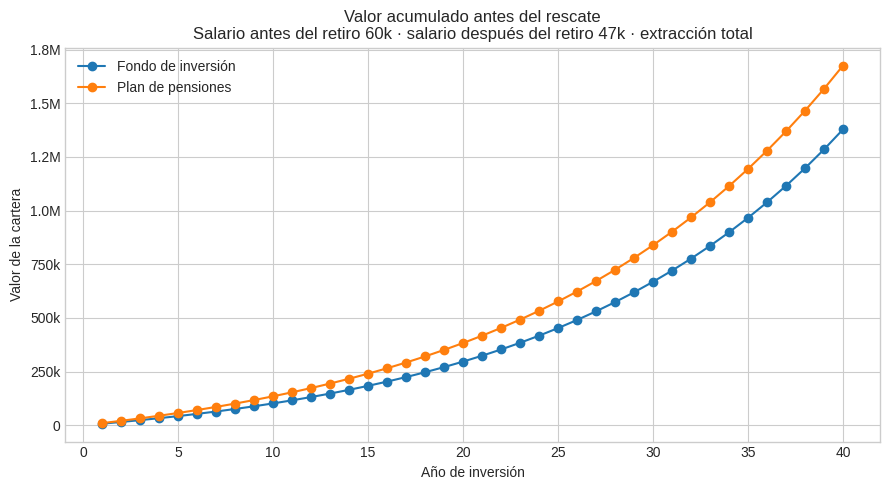

In [6]:
fig = plot_accumulation_history(primary_history)
fig.axes[0].set_title(
    "Valor acumulado antes del rescate\n"
    f"{nombre_grafica_salarios(PRIMARY_SCENARIO['config'], None)}"
)
fig.tight_layout()
plt.show()

## 2. Rescate total

Ya tenemos el valor acumulado. Ahora hacemos la prueba más bruta: liquidar toda la cartera en un único año y comparar cuánto dinero neto queda después de impuestos.

In [7]:
primary_lump_sum = lump_sum_results(primary_config)
tabla_es(primary_lump_sum)

             Vehículo  Aportación bruta acumulada  Valor antes del rescate  \
0  Fondo de inversión                  400,000.00             1,378,364.87   
1   Plan de pensiones                  400,000.00             1,675,620.64   

   Rescate bruto  Impuestos del rescate  Comisiones de salida  \
0   1,378,364.87             311,073.77                  0.00   
1   1,675,620.64             748,129.35                  0.00   

   Dinero neto final  CAGR neto efectivo  
0       1,067,291.09                0.02  
1         927,491.28                0.02  

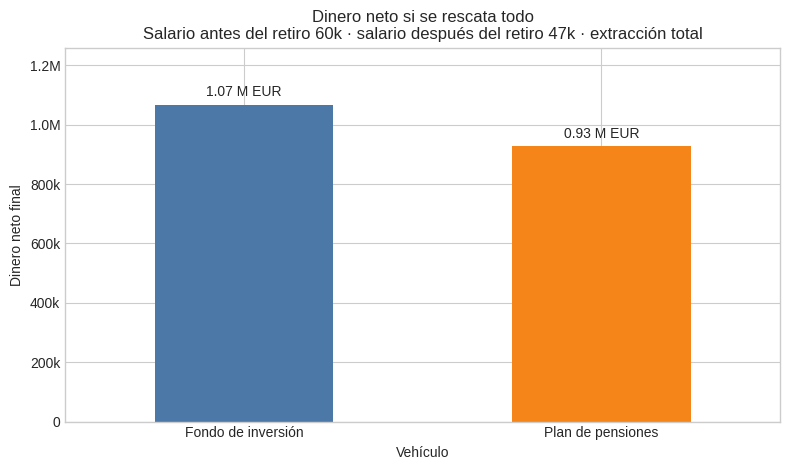

In [8]:
net_lump_sum = primary_lump_sum.set_index("vehicle")["final_after_tax_money"]
fig, ax = plt.subplots(figsize=(8, 4.8))
net_lump_sum.plot.bar(ax=ax, color=["#4c78a8", "#f58518"])
ax.set_title(
    f"Dinero neto si se rescata todo\n{nombre_grafica_salarios(PRIMARY_SCENARIO['config'], None)}"
)
ax.set_xlabel("Vehículo")
ax.set_ylabel("Dinero neto final")
apply_money_axis(ax, "y")
ax.tick_params(axis="x", rotation=0)

labels = [f"{value / 1_000_000:.2f} M EUR" for value in net_lump_sum]
ax.bar_label(ax.containers[0], labels=labels, padding=4)
ax.margins(y=0.18)
fig.tight_layout()
plt.show()

A primera vista, el plan parecía ir ganando porque acumulaba más patrimonio bruto. La sorpresa llega al pedir el dinero neto: después del rescate, queda por detrás.

La lectura es importante para cualquiera que esté comparando vehículos de inversión: no basta con mirar cuánto dinero hay dentro; hay que mirar cuánto queda fuera, ya limpio de impuestos.

Ahora descomponemos el rescate bruto para ver qué parte acaba como dinero disponible y qué parte se la lleva Hacienda.

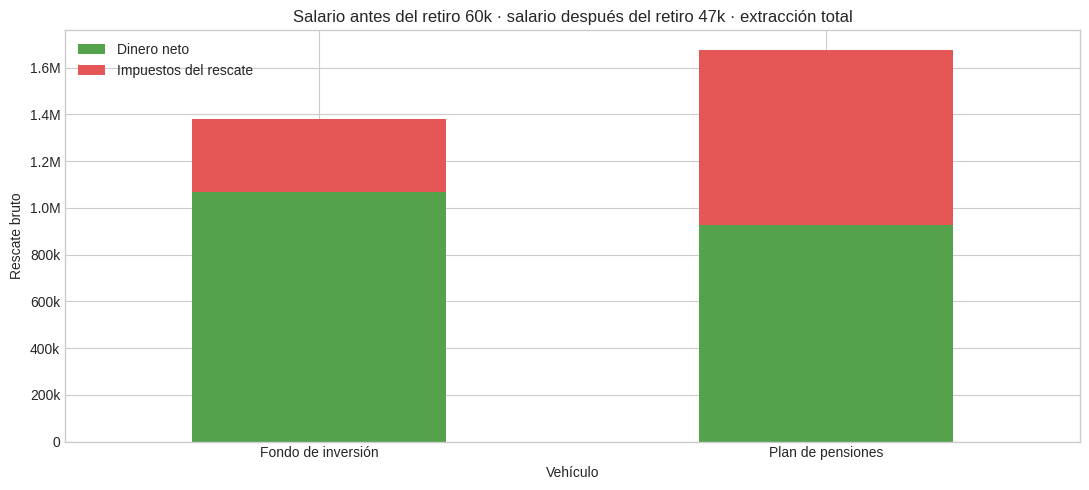

In [9]:
primary_lump_sum_decomposition = normalize_lump_sum_extraction_results(
    primary_lump_sum,
    scenario_name=PRIMARY_SCENARIO["name"],
)
plot_extraction_comparison_breakdown(
    primary_lump_sum_decomposition,
    title=nombre_grafica_salarios(PRIMARY_SCENARIO["config"], None),
)
plt.show()

La diferencia aparece en el bloque de impuestos. El plan paga IRPF por todo el rescate, porque ese dinero sale como renta del trabajo. El fondo paga solo por la ganancia patrimonial, no por recuperar el capital que ya tributó antes de invertirse.

Primera regla práctica: rescatar un plan de pensiones entero de golpe suele ser fiscalmente agresivo. Puede haber casos concretos donde tenga sentido, pero no es el uso natural del producto.

## 3. Rescates parciales

Rescatarlo todo concentra demasiada renta en un solo ejercicio. Probemos una estrategia más razonable: extraer cada año un porcentaje pequeño del valor de la cartera. Extraeremos un 4%.

             Vehículo  Aportación bruta acumulada  Valor antes del rescate  \
0  Fondo de inversión                  400,000.00             1,378,364.87   
1   Plan de pensiones                  400,000.00             1,675,620.64   

   Porcentaje de extracción  Rescate bruto  Impuestos del rescate  \
0                      0.04      55,134.59              10,606.33   
1                      0.04      67,024.83              27,980.74   

   Comisiones de salida  Dinero neto recibido  Tipo efectivo  
0                  0.00             44,528.26           0.19  
1                  0.00             39,044.08           0.42  

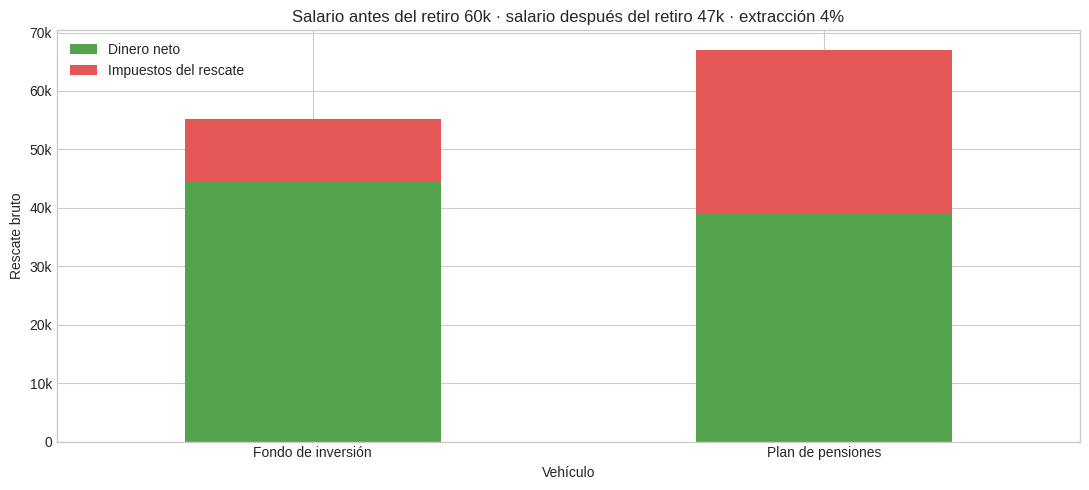

In [10]:
withdrawal_rate = 0.04
primary_3_results = percentage_withdrawal_results(primary_config, withdrawal_rate)
ipy_display(tabla_es(primary_3_results))

primary_3_decomposition = normalize_percentage_extraction_results(
    primary_3_results,
    scenario_name=PRIMARY_SCENARIO["name"],
)
plot_extraction_comparison_breakdown(
    primary_3_decomposition,
    title=nombre_grafica_salarios(PRIMARY_SCENARIO["config"], withdrawal_rate),
)
plt.show()

Con un `4%`, el rescate deja de ser una bomba fiscal de un solo año. Aun así, la pensión máxima de `47k` ya ocupa una parte relevante de los tramos de IRPF, y el rescate del plan se coloca encima de esa pensión.

El fondo sigue compitiendo bien porque tributa solo por plusvalías. El punto clave no es solo cuánto rescatas, sino desde qué nivel de ingresos empieza a tributar ese rescate.

## 4. Salario al aportar y pensión al rescatar

El siguiente paso es mover dos variables a la vez:

- **Salario durante los años de aportación**: aproxima el tipo marginal que se evita al meter dinero en el plan.
- **Pensión pública o ingresos ya cobrados durante el rescate**: aproximan desde qué tramo empieza a tributar el dinero que sale del plan.

La lectura de los mapas es directa: `60k` o más representa una renta alta, `150k` representa una renta muy alta y `47k` representa una pensión máxima dentro del modelo. En los mapas, el verde significa que el plan deja más dinero neto que el fondo; el rojo significa que gana el fondo. La línea azul marca la frontera donde cambia el ganador.

In [11]:
salary_experiment_configs = {
    experiment["name"]: build_config(experiment["config"])
    for experiment in SALARY_HEATMAP_EXPERIMENTS
}
salary_heatmap_parameters = {
    experiment["name"]: {"name": experiment["name"], **experiment["heatmap"]}
    for experiment in SALARY_HEATMAP_EXPERIMENTS
}

In [12]:
salary_sensitivity_by_mode = {}
salary_heatmap_axes_by_mode = {}

for mode in SALARY_HEATMAP_EXTRACTION_MODES:
    salary_sensitivity_frames = []
    salary_heatmap_axes = {}
    for experiment in SALARY_HEATMAP_EXPERIMENTS:
        name = experiment["name"]
        sensitivity, axes = working_retirement_salary_sensitivity_results(
            {name: salary_experiment_configs[name]},
            {name: salary_heatmap_parameters[name]},
            steps=experiment["heatmap"]["steps"],
            min_model_gross_salary=MIN_MODEL_GROSS_SALARY,
            withdrawal_rate=mode["withdrawal_rate"],
        )
        salary_sensitivity_frames.append(sensitivity)
        salary_heatmap_axes.update(axes)

    salary_sensitivity_by_mode[mode["name"]] = pd.concat(
        salary_sensitivity_frames,
        ignore_index=True,
    )
    salary_heatmap_axes_by_mode[mode["name"]] = salary_heatmap_axes

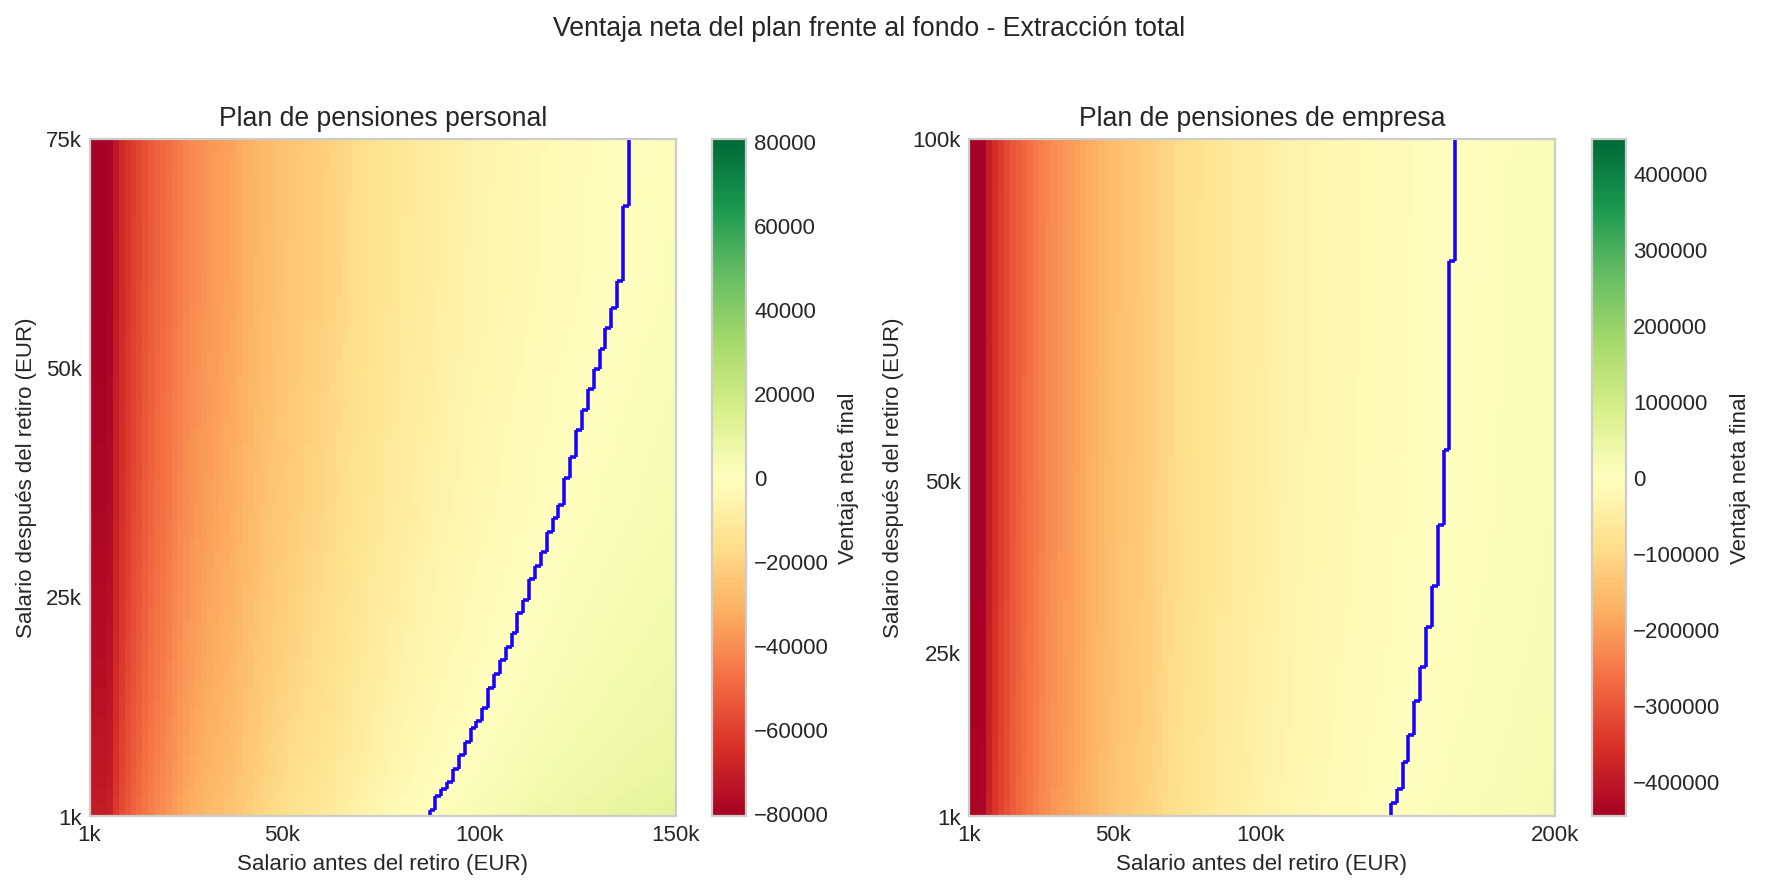

In [13]:
mode = SALARY_HEATMAP_EXTRACTION_MODES[0]
plot_salary_heatmaps(
    list(salary_heatmap_parameters.values()),
    salary_sensitivity_by_mode[mode["name"]],
    salary_heatmap_axes_by_mode[mode["name"]],
    figsize=(13, 5.5),
    colorbar_label=mode["colorbar_label"],
    title=f"Ventaja neta del plan frente al fondo - {mode['name']}",
)
plt.show()

En rescate total, el plan lo tiene difícil. Al concentrar décadas de ahorro en un solo año, el IRPF de salida domina incluso cuando la aportación se hizo desde salarios altos.

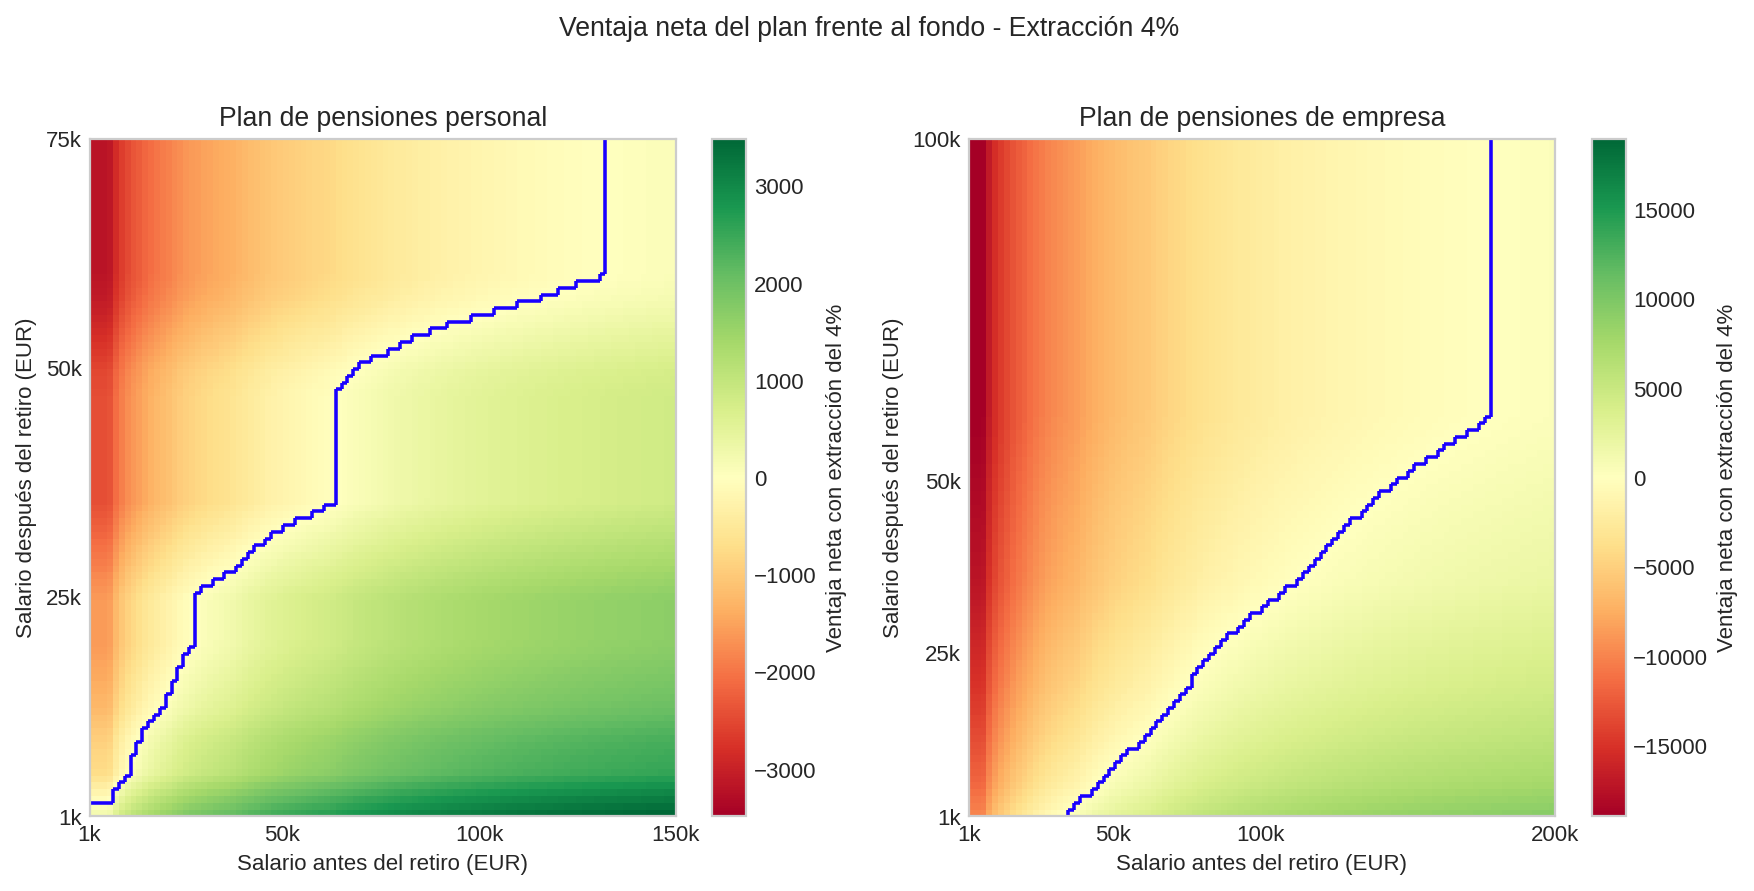

In [14]:
mode = SALARY_HEATMAP_EXTRACTION_MODES[1]
plot_salary_heatmaps(
    list(salary_heatmap_parameters.values()),
    salary_sensitivity_by_mode[mode["name"]],
    salary_heatmap_axes_by_mode[mode["name"]],
    figsize=(13, 5.5),
    colorbar_label=mode["colorbar_label"],
    title=f"Ventaja neta del plan frente al fondo - {mode['name']}",
)
plt.show()

Con rescates del `4%`, empiezan a aparecer más zonas donde el plan puede competir. La mejora viene de repartir el IRPF de salida en importes más pequeños y menos explosivos.

## 5. Comisión del plan y rentabilidad esperada

Hasta ahora hemos usado una rentabilidad base del `6,8%`. En esta sección dejamos que el modelo respire un poco: movemos la rentabilidad esperada entre `5%` y `9%`, alrededor de tres referencias (`5,1%`, `6,8%` y `8,5%`).

La pregunta es si el dinero extra que entra en el plan antes de IRPF crece lo suficiente como para compensar la tributación de salida y las comisiones adicionales.

In [15]:
fee_return_results = {}
fee_return_axes = {}
for experiment in FEE_RETURN_EXPERIMENTS:
    heatmap = experiment["heatmap"]
    sensitivity, axes = percentage_fee_return_sensitivity_grid_results(
        build_config(experiment["config"]),
        expected_return_min=heatmap["expected_return_min"],
        expected_return_max=heatmap["expected_return_max"],
        pension_fee_premium_min=heatmap["pension_fee_premium_min"],
        pension_fee_premium_max=heatmap["pension_fee_premium_max"],
        steps=heatmap["steps"],
        withdrawal_rate=experiment["withdrawal_rate"],
    )
    fee_return_results[experiment["name"]] = sensitivity
    fee_return_axes[experiment["name"]] = axes

Primero miramos el caso de salario `60k` y pensión máxima de `47k`.

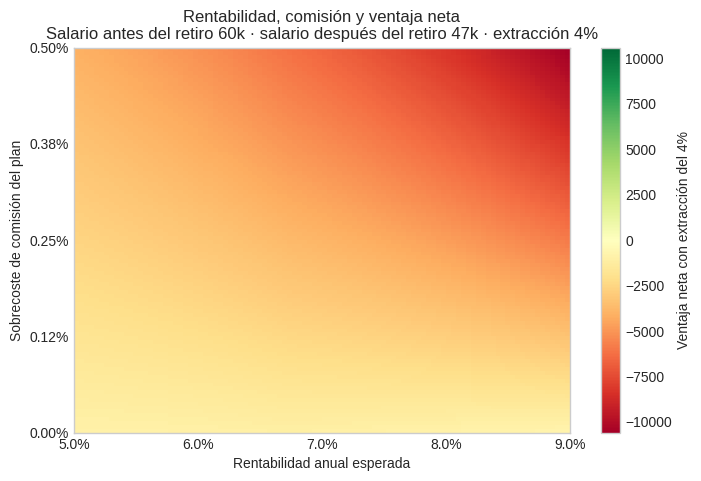

In [ ]:
experiment = FEE_RETURN_EXPERIMENTS[0]

heatmap = experiment["heatmap"]
axes = fee_return_axes[experiment["name"]]
plot_fee_return_sensitivity(
    fee_return_results[experiment["name"]],
    title=(
        "Rentabilidad, comisión y ventaja neta\n"
        f"{nombre_grafica_salarios(experiment['config'], experiment['withdrawal_rate'])}"
    ),
    colorbar_label=f"Ventaja neta con extracción del {format_extraction_rate_label(experiment['withdrawal_rate'])}",
    expected_return_edges=axes["expected_return_edges"],
    pension_fee_premium_edges=axes["pension_fee_premium_edges"],
    expected_return_ticks=heatmap["expected_return_ticks"],
    pension_fee_premium_ticks=heatmap["pension_fee_premium_ticks"],
)
plt.show()

Con pensión máxima, el plan no encuentra espacio. La ventaja de aportar antes de IRPF se enfrenta a una salida que ya empieza desde una pensión alta.

Ahora subimos el salario a `150k`. Este perfil ya ha saturado la base de cotización mucho antes, pero sigue pudiendo aportar al plan desde tramos altos de IRPF.

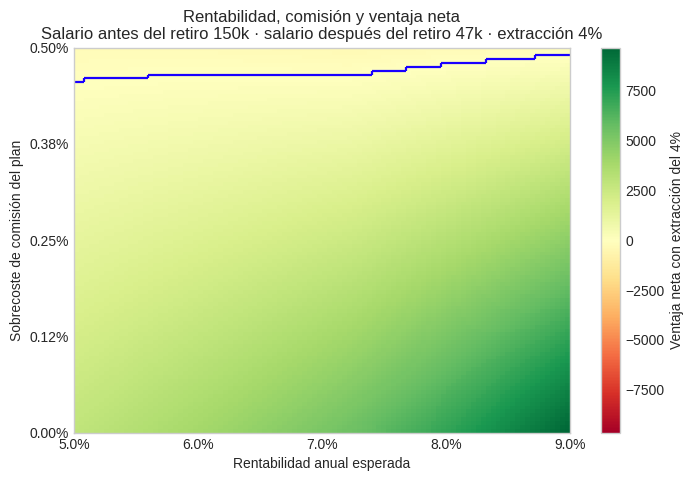

In [17]:
experiment = FEE_RETURN_EXPERIMENTS[1]

heatmap = experiment["heatmap"]
axes = fee_return_axes[experiment["name"]]
plot_fee_return_sensitivity(
    fee_return_results[experiment["name"]],
    title=(
        "Rentabilidad, comisión y ventaja neta\n"
        f"{nombre_grafica_salarios(experiment['config'], experiment['withdrawal_rate'])}"
    ),
    colorbar_label=f"Ventaja neta con extracción del {format_extraction_rate_label(experiment['withdrawal_rate'])}",
    expected_return_edges=axes["expected_return_edges"],
    pension_fee_premium_edges=axes["pension_fee_premium_edges"],
    expected_return_ticks=heatmap["expected_return_ticks"],
    pension_fee_premium_ticks=heatmap["pension_fee_premium_ticks"],
)
plt.show()

Aquí sí aparecen zonas verdes. Eso no significa que las comisiones dejen de importar: muchas ventajas son estrechas y dependen de una rentabilidad suficientemente alta. Sin embargo, la combinación de alta rentabilidad esperada y extremadamente bajas comisiones es una opción casi inexistente en planes de pensiones.

El último bloque usa un escenario de retirada temprana con pensión pública aproximada de `18,5k`.

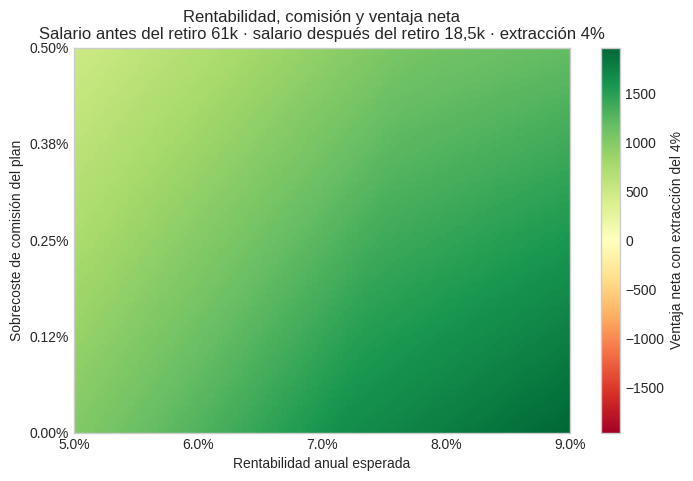

In [18]:
experiment = FEE_RETURN_EXPERIMENTS[2]
heatmap = experiment["heatmap"]
axes = fee_return_axes[experiment["name"]]
plot_fee_return_sensitivity(
    fee_return_results[experiment["name"]],
    title=(
        "Rentabilidad, comisión y ventaja neta\n"
        f"{nombre_grafica_salarios(experiment['config'], experiment['withdrawal_rate'])}"
    ),
    colorbar_label=f"Ventaja neta con extracción del {format_extraction_rate_label(experiment['withdrawal_rate'])}",
    expected_return_edges=axes["expected_return_edges"],
    pension_fee_premium_edges=axes["pension_fee_premium_edges"],
    expected_return_ticks=heatmap["expected_return_ticks"],
    pension_fee_premium_ticks=heatmap["pension_fee_premium_ticks"],
)
plt.show()

Con una pensión pública menor, el plan empieza a tener más margen. La explicación no es que el plan sea universalmente superior, sino que el rescate se suma sobre una base de ingresos más baja.

## 6. Tres casos concretos de extracción

Para cerrar, miramos tres fotos concretas. Los mapas anteriores ayudan a ver la frontera general; estos casos sirven para aterrizar la intuición.

In [19]:
final_case_decompositions = {}


def mostrar_caso_final(case: dict) -> None:
    """Muestra los resultados detallados de un caso final específico.

    Parameters
    ----------
    case : dict
        Diccionario con la configuración del caso a mostrar, con las claves "name", "config" y
        "withdrawal_rates".
    """
    config = build_config(case["config"])
    for withdrawal_rate in case["withdrawal_rates"]:
        results = percentage_withdrawal_results(config, withdrawal_rate)
        ipy_display(tabla_es(results))
        decomposition = normalize_percentage_extraction_results(
            results,
            scenario_name=case["name"],
        )
        final_case_decompositions[(case["name"], withdrawal_rate)] = decomposition
        plot_extraction_comparison_breakdown(
            decomposition,
            title=nombre_grafica_salarios(case["config"], withdrawal_rate),
        )
        plt.show()

Primer caso: salario `150k`, pensión máxima de `47k` y `40 años` de aportación. La pensión está capada, pero el ahorro fiscal al aportar ocurre en tramos altos.

             Vehículo  Aportación bruta acumulada  Valor antes del rescate  \
0  Fondo de inversión                  400,000.00             1,192,253.70   
1   Plan de pensiones                  400,000.00             1,675,620.64   

   Porcentaje de extracción  Rescate bruto  Impuestos del rescate  \
0                      0.04      47,690.15               9,141.01   
1                      0.04      67,024.83              27,980.74   

   Comisiones de salida  Dinero neto recibido  Tipo efectivo  
0                  0.00             38,549.14           0.19  
1                  0.00             39,044.08           0.42  

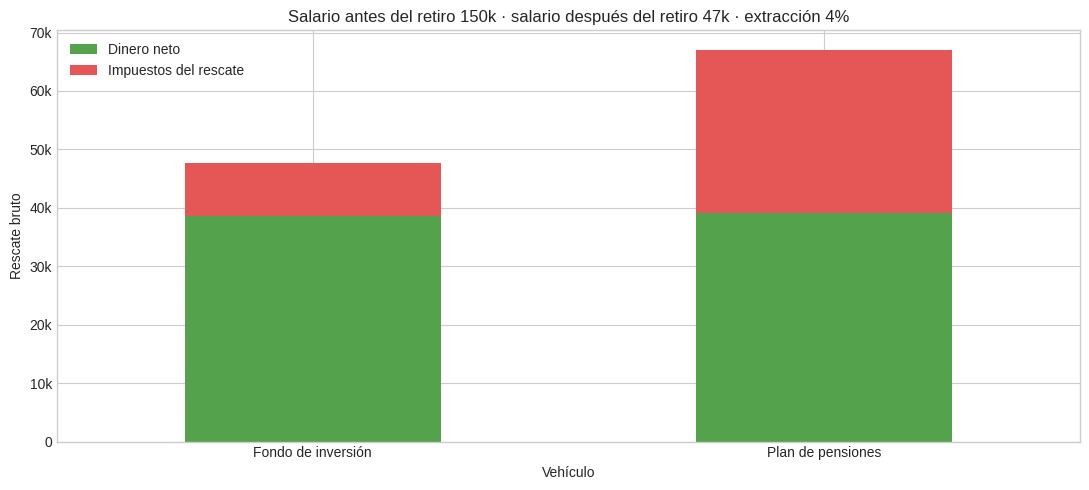

In [20]:
mostrar_caso_final(FINAL_EXTRACTION_CASES[0])

Este caso muestra por qué el plan puede empezar a tener sentido para rentas muy altas. La pensión pública no sube indefinidamente con el salario, pero el ahorro fiscal al aportar sí puede producirse en tramos altos.

Aun así, la ventaja no es automática. Puede ser pequeña y depende mucho de la comisión del plan y de la rentabilidad esperada.

Una lectura diferente algo cínica: si el resultado neto queda parecido, el plan también puede verse como una forma de trasladar impuestos desde la España de hoy a la España del futuro. Hacienda cobrará, pero quizá dentro de 40 años.

Segundo caso: retirada cerca de los 50 tras `20 años` trabajando alrededor de `60k`. Todavía no hay pensión pública, así que se modela un rescate anual medio del `6,8%` del plan. Las gallinas que entran por las que salen.

             Vehículo  Aportación bruta acumulada  Valor antes del rescate  \
0  Fondo de inversión                  200,000.00               295,951.94   
1   Plan de pensiones                  200,000.00               383,318.06   

   Porcentaje de extracción  Rescate bruto  Impuestos del rescate  \
0                      0.07      20,124.73               2,946.64   
1                      0.07      26,065.63               4,602.36   

   Comisiones de salida  Dinero neto recibido  Tipo efectivo  
0                  0.00             17,178.09           0.15  
1                  0.00             21,463.26           0.18  

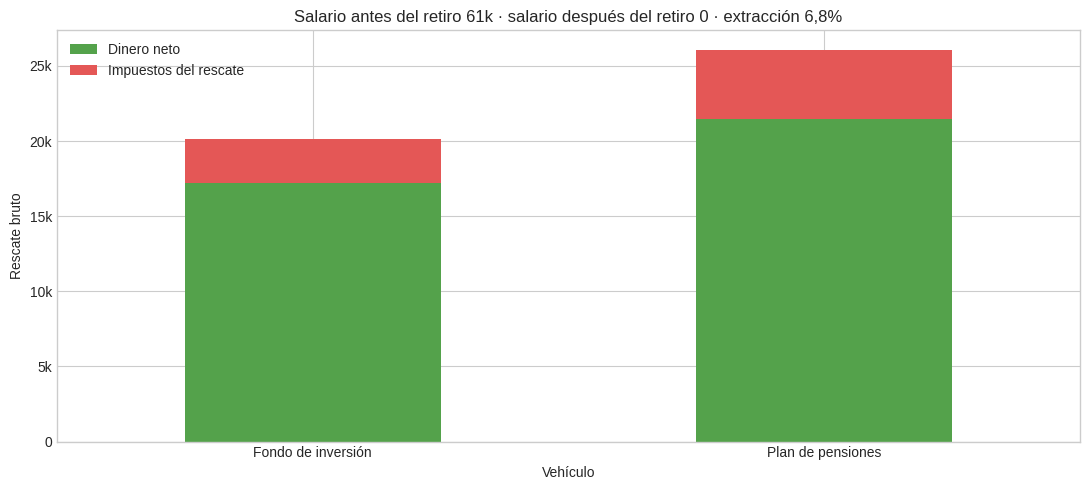

In [21]:
mostrar_caso_final(FINAL_EXTRACTION_CASES[1])

Sin pensión pública ocupando tramos de IRPF, el rescate del plan entra desde niveles más bajos. Esta es una de las situaciones donde el diferimiento fiscal encaja mejor, llegando a recibir más de 4000 euros extra al año.

Tercer caso: después de 20 años sin pensión, empieza una pensión pública aproximada de `18,5k`. El rescate baja al `4%`, con la idea de no forzar tanto el agotamiento de la cartera.

             Vehículo  Aportación bruta acumulada  Valor antes del rescate  \
0  Fondo de inversión                  200,000.00               295,951.94   
1   Plan de pensiones                  200,000.00               383,318.06   

   Porcentaje de extracción  Rescate bruto  Impuestos del rescate  \
0                      0.04      11,838.08               1,683.91   
1                      0.04      15,332.72               4,200.90   

   Comisiones de salida  Dinero neto recibido  Tipo efectivo  
0                  0.00             10,154.17           0.14  
1                  0.00             11,131.82           0.27  

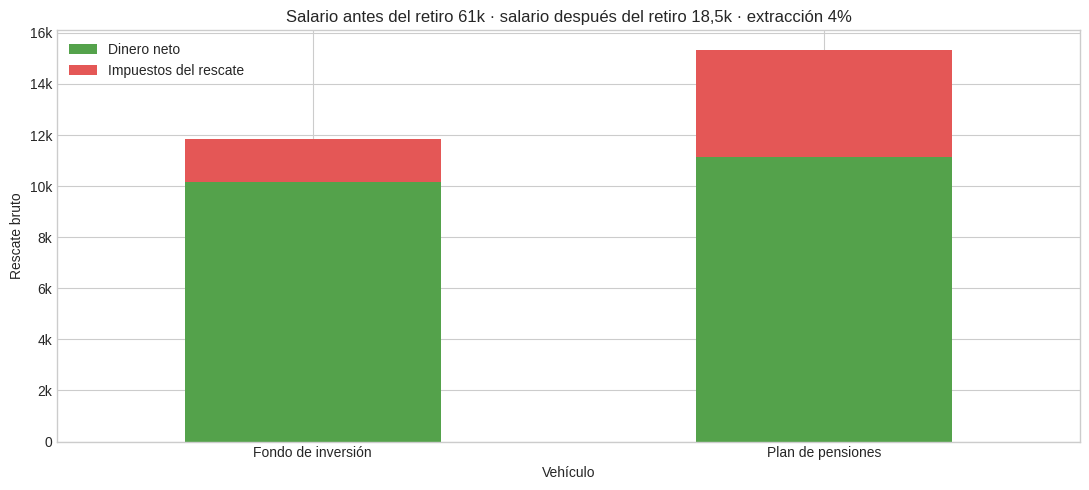

In [22]:
mostrar_caso_final(FINAL_EXTRACTION_CASES[2])

Con `18,5k` de pensión, el plan sigue teniendo más margen que con pensión máxima, pero parte de los tramos ya están ocupados. La ventaja no desaparece necesariamente, aunque se estrecha, siendo inferior a 1000 euros al año.

Podrás disfrutar de un par de fines de semana de vacaciones extra al año.

## Conclusiones

Un plan de pensiones no elimina el IRPF: lo aplaza. Su ventaja aparece cuando aportas en años con tipos marginales altos y rescatas en años con ingresos más bajos, por ejemplo durante una retirada temprana, antes de cobrar pensión pública o si esperas una pensión claramente inferior a tu salario actual.

Si te jubilas a la edad ordinaria con una pensión pública alta o cercana a la máxima, el plan casi nunca parece especialmente atractivo. El rescate se suma a la pensión como renta del trabajo, por lo que puedes acabar tributando a tipos parecidos a los que intentaste evitar al aportar.

Frente a eso, el fondo indexado es más simple y flexible: inviertes después de impuestos, pero al vender solo tributan las ganancias. En el plan de pensiones, en cambio, todo lo rescatado tributa como renta del trabajo, por lo que rescatar grandes cantidades de golpe suele ser una mala estrategia.

La conclusión práctica no es “plan de pensiones sí” o “plan de pensiones no”. El plan solo tiene sentido si hay una estrategia fiscal clara: aportar cuando el IRPF es alto, rescatar cuando los ingresos son bajos, evitar rescates masivos y vigilar que las comisiones no destruyan la ventaja fiscal.